https://colab.research.google.com/drive/1BFEUBh2qjgWZLHd_iMb4FRLgywPwxinX#scrollTo=ETk8jHjyHvd2

https://www.kaggle.com/datasets/rashikrahmanpritom/plant-disease-recognition-dataset

https://colab.research.google.com/drive/15WTn5j9gk4_DHu6HQCnRqllPqVzLiR6B#scrollTo=0EZ-5MR5KWjg

Dataset "Plant Disease Recognition" do tác giả Rashik Rahman chia sẻ trên Kaggle là một tập dữ liệu hình ảnh dạng thu nhỏ (lightweight), chuyên dùng cho các bài toán Thị giác máy tính (Computer Vision) và Học sâu (Deep Learning) nhằm nhận diện bệnh ở thực vật.

1. Tổng quan về dữ liệuTổng số lượng ảnh: Khoảng 1.530 bức ảnh.   Các nhãn (Classes/Labels): Dataset này phân loại tình trạng của lá cây thành 3 nhóm chính:Healthy: Lá cây khỏe mạnh, không có dấu hiệu bệnh.   Powdery: Lá cây bị bệnh phấn trắng (Powdery Mildew) - một loại bệnh nấm phổ biến gây ra lớp bột màu trắng trên bề mặt lá.   Rust: Lá cây bị bệnh gỉ sắt (Rust) - biểu hiện bằng các đốm màu cam, nâu hoặc đỏ gỉ sắt do nấm gây ra.   Cấu trúc thư mục: Dữ liệu đã được chia sẵn thành các tập:Train (Tập huấn luyện)Test (Tập kiểm thử)   Validation (Tập xác thực)   

2. Mục đích sử dụng
Học tập và Nghiên cứu: Rất phù hợp cho người mới bắt đầu học về Deep Learning, cách xây dựng mạng nơ-ron tích chập (CNN) hoặc áp dụng các mô hình học chuyển giao (Transfer Learning như ResNet, VGG, MobileNet) để phân loại ảnh.

Ứng dụng thực tế: Xây dựng mô hình nguyên mẫu (prototype) cho các ứng dụng nông nghiệp thông minh (Smart Agriculture) giúp nông dân phát hiện sớm bệnh của cây trồng qua điện thoại hoặc camera.

Ưu điểm: Vì dung lượng và số lượng ảnh vừa phải (1.530 ảnh), dataset này chạy rất nhanh trên các môi trường miễn phí như Kaggle Notebook hoặc Google Colab mà không đòi hỏi tài nguyên GPU quá mạnh.

3. Gợi ý cách tiếp cận khi làm việc với dataset nàyTiền xử lý ảnh (Preprocessing): Resize tất cả các ảnh về cùng một kích thước (ví dụ: $224 \times 224$ hoặc $128 \times 128$ pixels) và chuẩn hóa (normalize) giá trị pixel về khoảng $[0, 1]$ hoặc $[-1, 1]$.Tăng cường dữ liệu (Data Augmentation): Do số lượng ảnh không quá lớn, bạn nên áp dụng các kỹ thuật augmentation (xoay ảnh, lật ngang/dọc, phóng to, thay đổi độ sáng) trong quá trình train để mô hình học tốt hơn và tránh bị hiện tượng quá khớp (overfitting).Xây dựng mô hình:Có thể tự thiết kế một mạng CNN cơ bản từ đầu ( gồm các lớp Conv2D, MaxPooling, Dropout, Dense).Hoặc sử dụng Transfer Learning (lấy các mô hình đã huấn luyện sẵn trên ImageNet) để đạt độ chính xác cao hơn nhanh chóng.

In [1]:
!pip -q install datasets evaluate
!pip -q install --upgrade accelerate
!pip install -q kaggle
!pip install datasets huggingface_hub -q
!pip install --upgrade transformers
!pip install onnx onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 25.0 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.18.0
    Uninstalling transformers-5.18.0:
      Successfully uninstalled transformers-5.18.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 75.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 45.2 MB/s eta 0:00:00


In [2]:
import torch
import torchvision
import gradio as gr
from PIL import Image
import numpy as np
import evaluate
from datasets import load_dataset
from huggingface_hub import notebook_login
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from transformers import DefaultDataCollator
from datasets import load_dataset
from huggingface_hub import notebook_login
from transformers import AutoImageProcessor
from torchvision.transforms import RandomResizedCrop, Resize, Compose, Normalize, ToTensor, RandomHorizontalFlip
from transformers import AutoModelForImageClassification, TrainingArguments, Trainer
from transformers import AutoImageProcessor, AutoModelForImageClassification
import torch
from PIL import Image
import requests
import matplotlib.pyplot as plt

1. Thư viện cốt lõi và xử lý số liệu
import torch: Thư viện PyTorch chính, dùng để tạo tensor, xây dựng mạng nơ-ron và thực hiện các tính toán trên CPU/GPU.

import numpy as np: Thư viện NumPy dùng để tính toán ma trận và xử lý mảng số liệu đa chiều trong Python.

import requests: Thư viện dùng để gửi các yêu cầu HTTP (ví dụ: tải một bức ảnh từ một đường dẫn URL trên internet về máy).



2. Xử lý và biến đổi hình ảnh
from PIL import Image: Thư viện Pillow (PIL) giúp đọc, ghi, hiển thị và chỉnh sửa các định dạng file hình ảnh.

import torchvision: Thư viện phụ trợ cho PyTorch, cung cấp các tập dữ liệu, mô hình và công cụ xử lý chuyên biệt cho thị giác máy tính.

from torchvision import datasets, transforms: Nhập các module chuyên dụng để tải dataset có sẵn và định nghĩa các phép biến đổi ảnh.

from torchvision.transforms import RandomResizedCrop, Resize, Compose, Normalize, ToTensor, RandomHorizontalFlip: Các công cụ cụ thể để tiền xử lý và tăng cường dữ liệu (data augmentation) cho ảnh:

Resize / RandomResizedCrop: Thay đổi kích thước hoặc cắt ảnh ngẫu nhiên.

ToTensor: Chuyển đổi ảnh dạng PIL/Numpy thành định dạng Tensor của PyTorch.

Normalize: Chuẩn hóa giá trị các kênh màu (RGB) về khoảng giá trị tiêu chuẩn.

RandomHorizontalFlip: Lật ngang ảnh ngẫu nhiên để tăng tính đa dạng cho dữ liệu train.

3. Quản lý dữ liệu và huấn luyện mô hình (Hugging Face & PyTorch)
from datasets import load_dataset: Hàm của Hugging Face dùng để tải và quản lý các tập dữ liệu (dataset) từ máy tính hoặc từ Hugging Face Hub.

from torch.utils.data import DataLoader: Công cụ của PyTorch giúp đóng gói dữ liệu thành từng batch nhỏ, xáo trộn (shuffle) và nạp vào mô hình một cách hiệu quả trong quá trình huấn luyện.

from transformers import DefaultDataCollator: Công cụ của Hugging Face giúp gom nhóm các mẫu dữ liệu lại với nhau thành một batch chuẩn chỉnh trước khi đưa vào mô hình Transformer.

from huggingface_hub import notebook_login: Hàm hỗ trợ đăng nhập tài khoản Hugging Face trực tiếp từ giao diện Jupyter Notebook hoặc Google Colab.

from transformers import AutoImageProcessor, AutoModelForImageClassification:

AutoImageProcessor: Tự động tải bộ tiền xử lý ảnh phù hợp với mô hình bạn chọn.

AutoModelForImageClassification: Tự động tải một mô hình học sâu đã được huấn luyện sẵn chuyên dùng cho bài toán phân loại ảnh (Image Classification).

from transformers import TrainingArguments, Trainer: Các lớp cốt lõi của Hugging Face giúp tự động hóa quá trình huấn luyện:

TrainingArguments: Cấu hình các tham số huấn luyện (số epoch, learning rate, batch size, thư mục lưu...).

Trainer: Trình quản lý vòng lặp huấn luyện, đánh giá và lưu mô hình mà bạn không cần tự viết vòng lặp for thủ công.

import evaluate: Thư viện Hugging Face dùng để tính toán các độ đo đánh giá mô hình (ví dụ: Accuracy, F1-Score, Precision...).

4. Trực quan hóa và Giao diện người dùng
import matplotlib.pyplot as plt: Thư viện dùng để vẽ biểu đồ hoặc hiển thị hình ảnh trực quan (ví dụ: vẽ biểu đồ loss/accuracy hoặc hiển thị bức ảnh đang dự đoán).

import gradio as gr: Thư viện giúp bạn dựng nhanh một ứng dụng web trực quan (UI) chỉ với vài dòng code để người dùng có thể tải ảnh lên và xem kết quả dự đoán của mô hình ngay lập tức.

In [3]:
! mkdir ~/.kaggle
! cp kaggle.json ~/.kaggle/

cp: cannot stat 'kaggle.json': No such file or directory


In [4]:
!chmod 600 /root/.kaggle/kaggle.json

chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [5]:
!kaggle datasets download -d rashikrahmanpritom/plant-disease-recognition-dataset

Dataset URL: https://www.kaggle.com/datasets/rashikrahmanpritom/plant-disease-recognition-dataset
License(s): CC0-1.0
100% 1.25G/1.25G [00:17<00:00, 75.1MB/s]



In [6]:
!unzip "/content/plant-disease-recognition-dataset.zip" -d "/content/dataset/"

Archive:  /content/plant-disease-recognition-dataset.zip
  inflating: /content/dataset/Test/Test/Healthy/8ddaa5a5caa5caa8.jpg  
  inflating: /content/dataset/Test/Test/Healthy/8ddaac1bd6c8cd0a.jpg  
  inflating: /content/dataset/Test/Test/Healthy/8ddd5ec1c0de38c4.jpg  
  inflating: /content/dataset/Test/Test/Healthy/8def3f60308ab41b.jpg  
  inflating: /content/dataset/Test/Test/Healthy/8def4d91382175c3.jpg  
  inflating: /content/dataset/Test/Test/Healthy/8df452e2e38c0b6e.jpg  
  inflating: /content/dataset/Test/Test/Healthy/8dfae9d78cc32089.jpg  
  inflating: /content/dataset/Test/Test/Healthy/8e3dbccdfe08c850.jpg  
  inflating: /content/dataset/Test/Test/Healthy/8e68163c62dc57d5.jpg  
  inflating: /content/dataset/Test/Test/Healthy/8e6a823cce9ff40c.jpg  
  inflating: /content/dataset/Test/Test/Healthy/8e77857194a59a87.jpg  
  inflating: /content/dataset/Test/Test/Healthy/8e79802b3fb770c8.jpg  
  inflating: /content/dataset/Test/Test/Healthy/8e7986d1ecd36445.jpg  
  inflating: /conten

Dataset Loading

In [7]:
plant_dataset = load_dataset(
    'imagefolder',
    data_dir='/content/dataset'
)

Resolving data files:   0%|          | 0/1532 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Hugging Face datasets để quét toàn bộ thư mục /content/dataset trên Google Colab và biến nó thành một đối tượng dữ liệu chuẩn của Hugging Face (DatasetDict).

'imagefolder': Đây là một trình nạp dữ liệu (data builder) mặc định của Hugging Face. Nó cực kỳ thông minh vì biết cách tự động đọc các thư mục chứa ảnh mà không cần bạn phải viết code thủ công từng bước.

data_dir='/content/dataset': Đây là đường dẫn đến thư mục gốc trên máy ảo Colab nơi bạn đã giải nén tập dữ liệu bệnh cây trồng từ Kaggle.

In [8]:
plant_dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 1532
    })
})

In [9]:
notebook_login()

để đăng nhập tài khoản Hugging Face trực tiếp từ trong Jupyter Notebook hoặc Google Colab.

In [ ]:
# repo_name = "plant-dataset" # Replace with your desired dataset name
# plant_dataset.push_to_hub(repo_name)

In [10]:
full_dataset = load_dataset("Folefac/plant-dataset", split="train")

README.md:   0%|          | 0.00/418 [00:00<?, ?B/s]

data/train-00000-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  466MB            

data/train-00000-of-00003.parquet: downloading bytes:           |  0.00B            

data/train-00001-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  447MB            

data/train-00001-of-00003.parquet: downloading bytes:           |  0.00B            

data/train-00002-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  440MB            

data/train-00002-of-00003.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/1532 [00:00<?, ? examples/s]

để tải trực tiếp một tập dữ liệu có sẵn trên Hugging Face Hub thay vì phải tự tải file zip từ Kaggle về rồi giải nén thủ công.

"Folefac/plant-dataset": Đây là tên đường dẫn định danh của tập dữ liệu trên kho lưu trữ Hugging Face. Trong đó Folefac là tên tài khoản (hoặc tổ chức) đã tải dataset này lên, và plant-dataset là tên của dataset.

split="train": Chỉ định rõ rằng bạn muốn lấy riêng phần dữ liệu thuộc tập huấn luyện (train) của dataset này về biến full_dataset.

In [11]:
full_dataset

Dataset({
    features: ['image', 'label'],
    num_rows: 1532
})

Data Splitting

In [12]:
# Split the dataset into training and the rest (validation + test)
train_rest = full_dataset.train_test_split(test_size=0.2)

# Split the rest (validation + test) into validation and test sets
test_valid = train_rest['test'].train_test_split(test_size=0.5)

# Assign the splits to new variables
train_dataset = train_rest['train']
validation_dataset = test_valid['train']
test_dataset = test_valid['test']

print("Training dataset size:", len(train_dataset))
print("Validation dataset size:", len(validation_dataset))
print("Test dataset size:", len(test_dataset))

Training dataset size: 1225
Validation dataset size: 153
Test dataset size: 154


chia tập dữ liệu (full_dataset) thành 3 phần tiêu chuẩn: Train (Huấn luyện), Validation (Xác thực) và Test (Kiểm thử) theo tỷ lệ thông thường là 80% - 10% - 10%.

train_test_split(test_size=0.2): Cắt tập dữ liệu thành 2 phần:

80% dữ liệu được đưa vào train_rest['train'] (đây sẽ là tập huấn luyện chính thức).

20% dữ liệu còn lại được đưa vào train_rest['test'] (phần này chứa cả dữ liệu cho Validation và Test).

Data Visualization

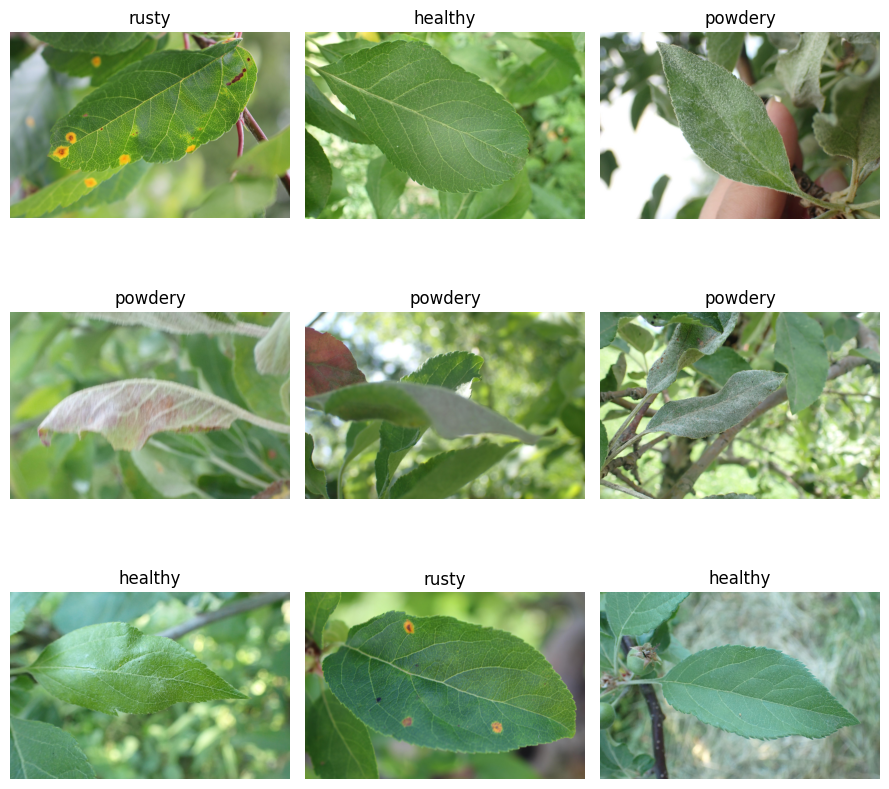

In [13]:
label_names = {
   0: "healthy",
   1: "powdery",
   2: "rusty",
}

num_rows = 3
num_cols = 3

plt.figure(figsize=(num_cols * 3, num_rows * 3))
indices = np.random.choice(range(len(train_dataset)), size=9, replace=False)

for i, idx in enumerate(indices, 1):
    idx = int(idx)
    image = train_dataset[idx]['image']
    label = train_dataset[idx]['label']

    plt.subplot(num_rows, num_cols, i)
    plt.imshow(image)
    plt.title(label_names[label])
    plt.axis('off')

plt.tight_layout()
plt.show()

trực quan hóa ngẫu nhiên 9 bức ảnh từ tập huấn luyện

Data Preprocessing

In [14]:
checkpoint = "google/vit-base-patch16-224-in21k"
image_processor = AutoImageProcessor.from_pretrained(checkpoint)
normalize = Normalize(mean=image_processor.image_mean, std=image_processor.image_std)

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

để chuẩn bị bộ tiền xử lý hình ảnh (Image Processor) và các tham số chuẩn hóa dựa trên một mô hình Vision Transformer (ViT) có sẵn trên Hugging Face.

google/vit-base-patch16-224-in21k
base: Cấu hình kích thước chuẩn của mô hình.
patch16: Chia bức ảnh thành các ô nhỏ (patches) có kích thước $16 \times 16$ pixels để đưa vào mạng transformer.
224: Yêu cầu ảnh đầu vào phải có kích thước chuẩn là $224 \times 224$ pixels.
in21k: Mô hình này đã được huấn luyện trước (pre-trained) trên tập dữ liệu khổng lồ ImageNet-21k.

image_processor = AutoImageProcessor.from_pretrained(checkpoint)
Hàm AutoImageProcessor.from_pretrained() tự động tải cấu hình và công cụ tiền xử lý ảnh đi kèm với mô hình google/vit-base-patch16-224-in21k.

Trình xử lý này biết chính xác mô hình gốc được huấn luyện với kích thước ảnh bao nhiêu, cách cắt, thay đổi kích thước và các thông số màu sắc nào để đảm bảo tính tương thích tuyệt đối.

normalize = Normalize(mean=image_processor.image_mean, std=image_processor.image_std)
image_processor.image_mean và image_processor.image_std: Lấy ra giá trị trung bình (mean) và độ lệch chuẩn (std) của 3 kênh màu RGB mà mô hình gốc đã dùng khi huấn luyện trên ImageNet.

Normalize(...): Tạo ra một phép biến đổi (transform) của PyTorch dùng để điều chỉnh lại giá trị các điểm ảnh (pixel) về đúng phân phối mà mô hình ViT mong đợi, giúp quá trình học tập (training) diễn ra ổn định và đạt độ chính xác cao nhất.

In [15]:
train_transforms = Compose([
    RandomResizedCrop((224,224)),
    RandomHorizontalFlip(p=0.5),
    ToTensor(),
    normalize
])

val_transforms = Compose([
    Resize((224,224)),
    ToTensor(),
    normalize
])

def apply_transforms(examples):
    examples["pixel_values"] = [train_transforms(img.convert("RGB")) for img in examples["image"]]
    del examples["image"]
    return examples

def apply_val_transforms(examples):
    examples["pixel_values"] = [val_transforms(img.convert("RGB")) for img in examples["image"]]
    del examples["image"]
    return examples

để định nghĩa các phép biến đổi (transforms) cho ảnh và tạo các hàm áp dụng chúng hàng loạt lên tập dữ liệu huấn luyện và tập xác thực thông qua thư viện Hugging Face.

Compose([...]): Gom nhiều bước biến đổi ảnh lại thành một chuỗi thực hiện lần lượt.

RandomResizedCrop((224,224)): Cắt ngẫu nhiên một vùng của ảnh và đổi kích thước về chuẩn $224 \times 224$ pixels (giúp mô hình học được đối tượng ở nhiều góc độ và kích cỡ khác nhau).

RandomHorizontalFlip(p=0.5): Lật ngang ngẫu nhiên bức ảnh với xác suất 50% (p=0.5), giúp tăng cường dữ liệu (data augmentation) để mô hình không bị học vẹt.

ToTensor(): Chuyển đổi định dạng ảnh từ thư viện PIL (hoặc mảng Numpy) thành tensor của PyTorch, đồng thời đưa giá trị các điểm ảnh về khoảng $[0, 1]$.

normalize: Áp dụng bước chuẩn hóa màu sắc (mean, std) theo đúng chuẩn của mô hình ViT mà ta đã thiết lập ở bước trước.

Resize((224,224)): Chỉ đơn thuần đổi kích thước ảnh về đúng chuẩn $224 \times 224$ pixels.

examples["image"]: Lấy ra danh sách các bức ảnh thô trong batch dữ liệu của Hugging Face.

img.convert("RGB"): Đảm bảo mọi bức ảnh đều được chuyển về hệ màu 3 kênh RGB (tránh lỗi nếu có ảnh dạng ảnh xám Grayscale hoặc ảnh trong suốt PNG có 4 kênh).

train_transforms(...): Chạy qua chuỗi các bước biến đổi đã định nghĩa ở trên.

examples["pixel_values"] = ...: Lưu kết quả vào một cột mới tên là pixel_values (đây là tên khóa chuẩn mà các mô hình Vision Transformer của Hugging Face yêu cầu cho dữ liệu đầu vào).

del examples["image"]: Xóa cột ảnh thô ban đầu đi để tiết kiệm bộ nhớ, chỉ giữ lại cột pixel_values đã qua xử lý.

In [16]:
train_data = train_dataset.with_transform(apply_transforms)
val_data = validation_dataset.with_transform(apply_val_transforms)
test_data = test_dataset.with_transform(apply_val_transforms)
data_collator = DefaultDataCollator()

để gắn các hàm biến đổi ảnh vừa viết vào các tập dữ liệu (train, validation, test) và chuẩn bị công cụ gom nhóm dữ liệu trước khi đưa vào quá trình huấn luyện.

.with_transform(...): Đây là một tính năng cực kỳ thông minh của thư viện Hugging Face. Thay vì xử lý và lưu trữ toàn bộ ảnh đã biến đổi lên ổ cứng hoặc RAM ngay từ đầu (tốn rất nhiều dung lượng), hàm này sẽ áp dụng hàm apply_transforms một cách tự động và trực tiếp (on-the-fly) ngay tại thời điểm mô hình gọi đến từng bức ảnh trong quá trình train.

train_data từ đây sẽ là tập dữ liệu huấn luyện đã được tích hợp sẵn các bước cắt ngẫu nhiên, lật ảnh, chuyển sang Tensor và chuẩn hóa.


data_collator = DefaultDataCollator()
DefaultDataCollator(): Đây là một công cụ mặc định của Hugging Face có nhiệm vụ gom nhóm (collate) các mẫu dữ liệu riêng lẻ thành một batch hoàn chỉnh (ví dụ: gom 16 hoặc 32 bức ảnh lại với nhau thành một tensor có kích thước chuẩn) để nạp thẳng vào vòng lặp huấn luyện của mô hình.

Modeling and Training

In [17]:
id2label = label_names
label2id = {v: k for k, v in id2label.items()}
print(id2label, label2id)

{0: 'healthy', 1: 'powdery', 2: 'rusty'} {'healthy': 0, 'powdery': 1, 'rusty': 2}


để tạo và chuyển đổi bảng ánh xạ giữa nhãn dạng số (ID) và nhãn dạng chữ (Label), đồng thời in kết quả ra màn hình để kiểm tra.

In [18]:
model = AutoModelForImageClassification.from_pretrained(
    checkpoint,
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
)

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.weight | UNEXPECTED | 
pooler.dense.bias   | UNEXPECTED | 
classifier.weight   | MISSING    | 
classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


tải mô hình Vision Transformer (ViT) gốc đã được huấn luyện sẵn và tiến hành tinh chỉnh (Fine-tuning) để phù hợp với bài toán phân loại 3 loại bệnh cây trồng của bạn.

1. AutoModelForImageClassification.from_pretrained(checkpoint, ...)
Hàm này tự động tải kiến trúc mô hình phân loại ảnh tương ứng với tên biến checkpoint (google/vit-base-patch16-224-in21k) cùng với toàn bộ trọng số (weights) đã được học sẵn từ bộ dữ liệu lớn ImageNet-21k.

2. Các tham số cấu hình tùy chỉnh:
num_labels=3: Khai báo số lượng lớp (nhãn) đầu ra của bài toán. Vì dataset của bạn có 3 trạng thái (Healthy, Powdery, Rusty), mô hình sẽ được thay đổi lớp phân loại cuối cùng (classification head) để xuất ra đúng 3 giá trị xác suất tương ứng.

id2label=id2label: Truyền từ điển ánh xạ từ số nguyên sang tên nhãn ({0: "healthy", 1: "powdery", 2: "rusty"}). Giúp mô hình gắn nhãn văn bản trực tiếp vào kết quả dự đoán.

label2id=label2id: Truyền từ điển nghịch đảo từ tên nhãn sang số nguyên ({"healthy": 0, "powdery": 1, "rusty": 2}).

In [19]:
accuracy = evaluate.load("accuracy")
def compute_metrics(evaluation_data):
    predictions, labels = evaluation_data
    predictions = np.argmax(predictions, axis=1)

    return accuracy.compute(predictions=predictions,
                            references=labels)

dùng để định nghĩa hàm tính toán độ chính xác (accuracy) cho mô hình trong quá trình huấn luyện và đánh giá thông qua thư viện evaluate của Hugging Face.

evaluate.load("accuracy"): Tải thước đo (metric) chuẩn có tên là "accuracy" từ thư viện Hugging Face. Công cụ này sẽ giúp so sánh kết quả mô hình đoán với nhãn thực tế để tính tỷ lệ dự đoán đúng.

evaluation_data: Hàm này nhận vào một tuple gồm hai thành phần: predictions (xác suất dự đoán của mô hình cho từng lớp) và labels (nhãn đúng thực tế của ảnh).

np.argmax(predictions, axis=1):

Mô hình Deep Learning thường trả về một mảng chứa các giá trị xác suất cho cả 3 nhãn (ví dụ: [0.1, 0.8, 0.1] tương ứng với tỷ lệ của healthy, powdery, rusty).

Hàm np.argmax có nhiệm vụ tìm vị trí (index) có giá trị xác suất lớn nhất theo chiều ngang (axis=1), qua đó chuyển mảng xác suất thành một con số nhãn cụ thể (ví dụ: chọn số 1 ứng với nhãn powdery).

accuracy.compute(...): So sánh danh sách các nhãn mà mô hình vừa dự đoán (predictions) với danh sách nhãn thực tế (references=labels), sau đó trả về kết quả độ chính xác (ví dụ: 0.95 tức là đạt 95% chính xác). Hàm này sẽ được truyền trực tiếp vào bộ quản lý Trainer để tự động chấm điểm mô hình sau mỗi vòng huấn luyện (epoch).

In [21]:
training_args = TrainingArguments(
    output_dir="./plant_outputs",
    remove_unused_columns=False,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-5,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    per_device_eval_batch_size=2,
    num_train_epochs=3,
    warmup_steps=100,  # Thay thế warmup_ratio bằng warmup_steps để tránh lỗi tương thích
    logging_steps=10,
    load_best_model_at_end=True,
    push_to_hub=True,
)

để cấu hình toàn bộ các tham số và thiết lập cho quá trình huấn luyện mô hình thông qua lớp TrainingArguments của Hugging Face.

1. Cấu hình lưu trữ và vận hành cơ bản
output_dir="./plant_outputs": Thư mục trên máy ảo (Colab) dùng để lưu lại các checkpoint (trọng số mô hình sau mỗi vòng train) và file kết quả.

remove_unused_columns=False: Giữ lại các cột dữ liệu không liên quan trực tiếp trong dataset mà không bị xóa tự động, giúp tránh lỗi khi dùng các hàm transform tùy chỉnh.

2. Chiến lược đánh giá và lưu mô hình
eval_strategy="epoch": Cứ sau mỗi epoch (một vòng duyệt qua toàn bộ tập dữ liệu train), mô hình sẽ tự động chạy đánh giá trên tập validation. (Lưu ý: Ở các phiên bản transformers cũ hơn, tham số này có tên là evaluation_strategy).

save_strategy="epoch": Cứ kết thúc mỗi epoch, hệ thống sẽ lưu lại trạng thái mô hình một lần.

load_best_model_at_end=True: Khi quá trình train kết thúc, hệ thống sẽ tự động nạp lại phiên bản mô hình đạt kết quả tốt nhất trên tập validation (thay vì lấy mô hình ở epoch cuối cùng, vốn có thể bị hiện tượng overfitting).

learning_rate=5e-5: Tốc độ học của mô hình ($0.00005$). Đây là mức learning rate chuẩn và an toàn khi tinh chỉnh (fine-tuning) các mô hình Vision Transformer.

per_device_train_batch_size=2: Số lượng ảnh trong một batch đưa vào huấn luyện trên mỗi thiết bị (GPU/CPU) ở mỗi bước. Con số nhỏ (2) giúp tiết kiệm bộ nhớ VRAM của GPU.

gradient_accumulation_steps=4: Tích lũy gradient qua 4 bước trước khi cập nhật trọng số.Ý nghĩa: Dù batch size thực tế trên GPU chỉ là 2, nhưng nhờ cơ chế tích lũy này, mô hình sẽ hoạt động hiệu quả tương đương với batch size lớn hơn ($2 \times 4 = 8$), giúp tối ưu hóa việc học khi bộ nhớ hạn chế.

per_device_eval_batch_size=2: Số lượng ảnh trong một batch khi đánh giá trên tập validation/test.

num_train_epochs=3: Tổng số vòng (epoch) huấn luyện mô hình duyệt qua toàn bộ tập dữ liệu là 3 vòng.

4. Tối ưu hóa và Đẩy lên Hub
warmup_steps=100: Số bước đầu tiên để tăng dần learning rate từ 0 lên đến mức 5e-5, giúp mô hình khởi động ổn định, tránh bị sốc trọng số ở giai đoạn đầu.

logging_steps=10: Cứ sau mỗi 10 bước train, hệ thống sẽ in ra các thông số (như mức độ lỗi - loss) để bạn theo dõi tiến trình.

push_to_hub=True: Tự động đẩy (upload) các checkpoint và mô hình sau khi train xong lên tài khoản cá nhân của bạn trên Hugging Face Hub (yêu cầu bạn đã chạy hàm notebook_login() trước đó).

In [23]:
trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=train_data,
    eval_dataset=val_data,
    processing_class=image_processor,
    compute_metrics=compute_metrics,
)

để khởi tạo đối tượng Trainer, đây là "trái tim" tự động hóa toàn bộ quy trình huấn luyện, đánh giá và quản lý mô hình của thư viện Hugging Face.

1. model=model
Truyền mô hình Vision Transformer đã được cấu hình 3 lớp phân loại bệnh cây trồng (model) vào để chuẩn bị huấn luyện.

2. args=training_args
Truyền bộ cấu hình tham số huấn luyện (training_args mà bạn vừa định nghĩa ở bước trước, bao gồm số epoch, learning rate, thư mục lưu, v.v.) để Trainer biết cần phải chạy theo chiến lược thế nào.

3. data_collator=data_collator
Truyền công cụ DefaultDataCollator() giúp gom các bức ảnh đơn lẻ thành từng batch chuẩn chỉnh trước khi đưa vào mô hình ở mỗi bước tính toán.

4. train_dataset=train_data
Chỉ định tập dữ liệu dùng để huấn luyện (train_data đã được gắn hàm apply_transforms cắt lật ảnh ngẫu nhiên).

5. eval_dataset=val_data
Chỉ định tập dữ liệu dùng để đánh giá và kiểm tra chéo trong suốt quá trình train (val_data dùng để chạy đánh giá sau mỗi epoch nhằm chọn mô hình tốt nhất).

6. processing_class=image_processor
processing_class (ở các phiên bản Transformers cũ thường dùng tên tham số là tokenizer): Truyền bộ xử lý ảnh (image_processor) vào để hệ thống tự động xử lý và đồng bộ hóa dữ liệu đầu vào sao cho khớp hoàn hảo với mô hình ViT. (Lưu ý: Thay đổi này giúp Hugging Face Trainer tự động nhận diện đây là bài toán thị giác máy tính thay vì xử lý văn bản).

7. compute_metrics=compute_metrics
Truyền hàm compute_metrics mà bạn đã định nghĩa trước đó (sử dụng thư viện evaluate để tính toán độ chính xác - Accuracy). Nhờ vậy, sau mỗi epoch, Trainer sẽ tự động gọi hàm này để chấm điểm mô hình trên tập validation và in kết quả ra màn hình cho bạn theo dõi.

In [ ]:
trainer.train()

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss


In [ ]:
outputs = trainer.predict(val_data)
print(outputs.metrics)

để chạy dự đoán (evaluation/prediction) trên toàn bộ tập dữ liệu validation (val_data) bằng mô hình vừa huấn luyện và in ra bảng các chỉ số đánh giá kết quả.

In [ ]:
model.push_to_hub("vit-plant")

để đẩy (upload) trực tiếp mô hình phân loại bệnh cây trồng đã được huấn luyện lên kho lưu trữ cá nhân của bạn trên Hugging Face Hub.

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = outputs.label_ids
y_pred = outputs.predictions.argmax(1)

labels = test_data.features["label"].names

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(xticks_rotation=45)

để tạo và vẽ biểu đồ Ma trận nhầm lẫn (Confusion Matrix) nhằm đánh giá chi tiết xem mô hình dự đoán đúng hay sai ở từng lớp bệnh cụ thể

In [ ]:
from transformers import pipeline, AutoImageProcessor

processor = AutoImageProcessor.from_pretrained("google/vit-base-patch16-224-in21k")
pipe = pipeline("image-classification", model="Folefac/vit-plant", image_processor=processor)

để khởi tạo một pipeline dự đoán (inference pipeline) của thư viện Hugging Face. Nó đóng gói toàn bộ quy trình xử lý ảnh và chạy mô hình, giúp bạn dễ dàng đưa một bức ảnh mới vào để mô hình tự động nhận diện bệnh cây.

In [ ]:
predictions = pipe("/content/dataset/Validation/Validation/Rust/8030a3a79fca6abb.jpg")

In [ ]:
print(predictions)

In [ ]:
def predict_disease(image):

  if image is None:
    return "Please upload an image."

  try:
    prediction = pipe(image)
    result = prediction[0]['label']
    return f"Prediction: {result}"
  except Exception as e:
    return f"An error occurred during prediction: {e}"

Gradio

In [ ]:
iface = gr.Interface(
    fn=predict_disease,

    inputs=gr.Image(
        type="pil",
        label="Upload Plant Image"
    ),

    outputs=gr.Textbox(
        label="Classification Result"
    ),
    title="Plant Disease Classifier (Healthy, Powdery, or Rusty)",
    description="Upload an image of a plant leaf. The system will classify its condition.",
)

iface.launch()

để xây dựng một giao diện web trực quan (Web UI) thông qua thư viện Gradio, giúp bạn dễ dàng tải ảnh lên và kiểm tra kết quả dự đoán của mô hình mà không cần viết code phức tạp.

Onnx

In [ ]:
!pip install onnx onnxruntime

Đây là bước chuẩn bị cốt lõi nếu bạn muốn chuyển đổi (export) mô hình Vision Transformer (ViT) từ định dạng PyTorch sang định dạng chuẩn ONNX.

In [ ]:
model  = AutoModelForImageClassification.from_pretrained("Folefac/vit-plant", return_dict=True)
#processor = AutoImageProcessor.from_pretrained("google/vit-base-patch16-224-in21k")

để tải lại mô hình đã được tinh chỉnh từ kho lưu trữ cá nhân của bạn trên Hugging Face Hub (Folefac/vit-plant) để chuẩn bị cho bước xuất file sang định dạng ONNX.

In [ ]:
dummy_input = torch.randn(1, 3, 224, 224)

để tạo ra một tensor dữ liệu giả (dummy input) có kích thước chuẩn để làm "mồi" khi xuất mô hình sang định dạng ONNX.

torch.randn(1, 3, 224, 224)
torch.randn(...): Tạo một tensor chứa các giá trị ngẫu nhiên tuân theo phân phối chuẩn.

Kích thước (1, 3, 224, 224) tương ứng với chuẩn đầu vào mà mô hình Vision Transformer yêu cầu:

1: Batch size (số lượng ảnh xử lý trong một lần, ở đây là 1 ảnh mẫu).

3: Số kênh màu (RGB - Đỏ, Xanh lá, Xanh dương).

224: Chiều cao của ảnh (224 pixels).

224: Chiều rộng của ảnh (224 pixels).

In [ ]:
input_names = ["pixel_values"]
output_names = ["logits"]

để định nghĩa tên cho các đầu vào (input) và đầu ra (output) của mô hình khi chuyển đổi sang định dạng ONNX.

In [ ]:
torch.onnx.export(
    model,
    dummy_input,
    "vit_classification.onnx",
    export_params=True,
    opset_version=14,
    do_constant_folding=True,
    input_names=input_names,
    output_names=output_names,
    dynamic_axes={"pixel_values": {0: "batch_size"}, "logits": {0: "batch_size"}},
)

lệnh chính thức để thực hiện việc chuyển đổi (export) mô hình PyTorch sang tệp định dạng chuẩn ONNX với tên gọi là vit_classification.onnx.

1. Các thành phần cốt lõi
model: Mô hình Vision Transformer (Folefac/vit-plant) đã được tải về bộ nhớ.

dummy_input: Dữ liệu ảnh giả (torch.randn(1, 3, 224, 224)) dùng để trace cấu trúc mạng.

"vit_classification.onnx": Đường dẫn và tên file tệp ONNX đầu ra sẽ được lưu trên ổ đĩa sau khi export thành công.

2. Các tham số tối ưu hóa nâng cao
export_params=True: Tự động lưu toàn bộ các trọng số (weights) đã được huấn luyện của mô hình vào bên trong tệp ONNX (nếu để False thì tệp chỉ chứa khung kiến trúc mà không có trọng số).

opset_version=14: Phiên bản ONNX Opset chuẩn (phiên bản 14 hỗ trợ rất tốt các toán tử của dòng Transformer và các mạng thị giác máy tính hiện đại).

do_constant_folding=True: Tối ưu hóa biểu đồ tính toán bằng cách tự động "gấp" các hằng số lại với nhau trước khi lưu, giúp giảm kích thước tệp và tăng tốc độ suy luận sau này.

3. Tên và tính linh hoạt của dữ liệu
input_names=input_names và output_names=output_names: Gắn tên định danh pixel_values cho đầu vào và logits cho đầu ra mà bạn đã cấu hình ở bước trước.

dynamic_axes={...}: Cấu hình trục động cho batch size. Bằng cách thiết lập này, tệp ONNX của bạn sẽ cực kỳ linh hoạt: nó có thể nhận đầu vào là 1 ảnh, 4 ảnh, hay bất kỳ số lượng ảnh nào trong một batch mà không bị ép buộc cố định ở con số 1 như lúc tạo dummy_input.

In [ ]:
test_img = Image.open("/content/dataset/Test/Test/Rust/82f49a4a7b9585f1.jpg")
resized_img = test_img.resize((224,224))
np_array = np.asarray(resized_img)
img = np.transpose(np_array, (2, 0, 1))
img = np.expand_dims(img, axis=0)
img = img.astype(np.float32)/255.

để tiền xử lý thủ công một bức ảnh thô từ ổ đĩa thành một mảng số liệu (numpy array) có cấu trúc và định dạng hoàn hảo để đưa vào mô hình ONNX dự đoán.

Image.open(...): Đọc tệp ảnh lá cây bị bệnh (thuộc nhóm Rust) từ đường dẫn trên Colab.

.resize((224, 224)): Ép kích thước ảnh về đúng chuẩn 224x224 pixels mà mô hình Vision Transformer yêu cầu.

np.asarray(...): Biến ảnh PIL thành mảng NumPy với kích thước ban đầu theo chuẩn ảnh thông thường là (Height, Width, Channel) tức là (224, 224, 3).

np.transpose(..., (2, 0, 1)): PyTorch và các mô hình xử lý ảnh chuẩn thường yêu cầu kênh màu lên trước, tức là định dạng Channel, Height, Width (3, 224, 224). Lệnh này hoán đổi vị trí các trục cho khớp với cấu trúc đó.

np.expand_dims(..., axis=0): Thêm một chiều ở đầu tiên để giả lập batch_size = 1, biến kích thước mảng từ (3, 224, 224) thành (1, 3, 224, 224) (khớp hoàn toàn với trục động dynamic_axes mà ta đã cấu hình khi xuất file ONNX).

.astype(np.float32) / 255.: Ép kiểu dữ liệu sang số thực (float32) và chia cho 255.0 để chuẩn hóa các giá trị điểm ảnh về khoảng từ 0.0 đến 1.0 (đây là khoảng giá trị mà mô hình học được khi train).

In [ ]:
import onnxruntime as ort

để nhập thư viện ONNX Runtime (ort), công cụ tăng tốc độ suy luận cốt lõi giúp chạy tệp mô hình .onnx với hiệu suất cực cao trên cả CPU lẫn GPU.

In [ ]:
providers=['CPUExecutionProvider']
session = ort.InferenceSession("vit_classification.onnx", providers=providers)

để khởi tạo phiên làm việc (Inference Session) của ONNX Runtime bằng cách chỉ định rõ phần cứng (execution provider) sẽ dùng để chạy mô hình.

In [ ]:
session_input = {session.get_inputs()[0].name: img}

để đóng gói dữ liệu đầu vào thành một từ điển (dictionary) đúng theo định dạng mà onnxruntime yêu cầu trước khi tiến hành chạy suy luận.

In [ ]:
onnx_output = session.run(None, session_input)
onnx_logits = onnx_output[0]
onnx_pred_idx = np.argmax(onnx_logits, axis=1)[0]
print(onnx_pred_idx)

bước chạy suy luận (inference) cuối cùng để thu về kết quả dự đoán từ mô hình ONNX, sau đó in ra chỉ số nhãn của loại bệnh mà mô hình nhận diện được.